Representación de la simulación del gas

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Cargo los datos
Posiciones = np.loadtxt("Posiciones_atomos_v_3.txt")

# Paso temporal
h = 0.002

# Quiero representar los primeros 8 segundos de la simulación y los ultimos 8 segundos, entonces el numero de frames será:
N_frames = int(1 / h)

#Estraigo los datos (Cada vector de posiciones tiene dimension N*100)
x_inicial = Posiciones[:N_frames, 0::2]
y_inicial = Posiciones[:N_frames, 1::2]
x_final = Posiciones[-N_frames:, 0::2]
y_final = Posiciones[-N_frames:, 1::2]


# FIgura para la simulación
fig, ax = plt.subplots(1,2, figsize=(12, 5))
ax[0].set_xlabel("x",fontsize=20)
ax[0].set_ylabel("y",fontsize=20)
ax[0].set_xlim([0, 22])
ax[0].set_ylim([0, 22])
ax[0].set_title("Posiciones iniciales de los átomos", fontsize=20, pad=20)
ax[0].plot(x_inicial[0, :], y_inicial[0, :], color = 'blue', marker = 'o', markersize = 3, linestyle = 'None')
ax[0].tick_params(axis="both", labelsize=20)
ax[1].set_xlabel("x",fontsize=20)
ax[1].set_ylabel("y",fontsize=20)
ax[1].set_xlim([0, 22])
ax[1].set_ylim([0, 22])
ax[1].set_title("Posiciones finales de los átomos", fontsize=20, pad=20)
ax[1].tick_params(axis="both", labelsize=20)

# Creo las líneas que representan cada átomo
line_final, = ax[1].plot([], [], color = 'blue', marker = 'o', markersize = 3, linestyle = 'None')

# Creo un texto para mostrar el tiempo en cada frame
tiempo = ax[1].text(0.02, 0.95, "", transform=ax[1].transAxes, fontsize=10, bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

#**************************************Función de animación*******************************************************
def animate(i):

    t_final = 249 + (i + 1) * h

    line_final.set_data(x_final[i, :], y_final[i, :])

    # Actualizo el tiempo correspondiente a cada frame
    tiempo.set_text(f"t = {t_final:.3f}") 

    return line_final, tiempo

ani = animation.FuncAnimation(fig, animate, N_frames, interval = 20, blit = True)

ani.save("animacion_Lennard_Jones_v_3.gif", writer='pillow', dpi = 150)

Calculo la energía cinética, potencial y mecánica

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

#************************Calculo la energia cinetica de las 100 particulas en un tiempo t, por unidad de masa*************

# Extraigo los datos de las posiciones y velocidades de los ficheros
Posiciones = np.loadtxt("Posiciones_atomos_v_5.txt")
Velocidades = np.loadtxt("Velocidades_atomos_v_5.txt")

# Extraigo las velocidades v_x e v_y 
v_x = Velocidades[:, 0::2] # Matriz de 125001 por 100
v_y = Velocidades[:, 1::2]

def energia_cinetica(v_x, v_y):

    v=np.sqrt((v_x)**2+(v_y)**2)
    T_paticula_t=0.5*v**2 #matriz de 125001 por 100, en cada termino energia cinetica de cada particula en distintos tiempos
    T_total=np.sum(T_paticula_t, axis=1) #suma sobre particulas en cada instante
    return T_total #array (125001,)

#***********************Calculo la energia potencial de las 100 particulas en un tiempo t, por unidad de masa*****************

#Defino las matrices de posiciones x e y a partir del fichero posiciones.txt

x = Posiciones[:, 0::2]
y = Posiciones[:, 1::2]

def energia_potencial(x,y): 
    V_t=np.zeros(x.shape) #se inicializa matriz con forma (n_tiempos, n_particulas)

    for i in range(x.shape[1]): 
        for j in range(x.shape[1]):
            if i < j: #evito contar dos veces la misma interaccion

                # Distancias para todos los tiempos entre particula i y j
                dx=np.abs(x[:,i]-x[:,j]) #array (125001, 1)
                dy=np.abs(y[:,i]-y[:,j]) #array (125001,1)


                # Comprobacion elemento a elemento de dx y dy > 11 (condiciones periodicas)
                dx=np.where(dx>11, 22-dx, dx) # where es una funcion de numpy que hace una comprobacion elemento a elemento, si se cumple la condicion dx>11, entonces se asigna el valor 22-dx, y si no se cumple, se asigna el valor dx
                dy=np.where(dy>11, 22-dy, dy)

                rij=np.sqrt(dx**2+dy**2) 

                # Comprobacion elemento a elemento: 0 < rij < 3
                cond=(rij>0) & (rij<3)

                # Solo actualizo donde se cumple la condicion
                V_t[cond,i] = V_t[cond,i] + 4*(1/(rij[cond]**12)-1/(rij[cond]**6))
    V_total_t=np.sum(V_t, axis=1) #energia potencial total en cada instante
    return V_total_t #array (125001,1)

T=energia_cinetica(v_x, v_y)
V=energia_potencial(x,y)

#***********************Energía mecánica******************************************************

E=T+V

# Guardo T, E Y V en un fichero
np.savetxt("Energia_cinetica_potencial_total_v_5.txt", np.array([T, V, E]).T, header="Energia_cinetica Energia_potencial Energia_total", fmt="%.18e")

Representación de energías

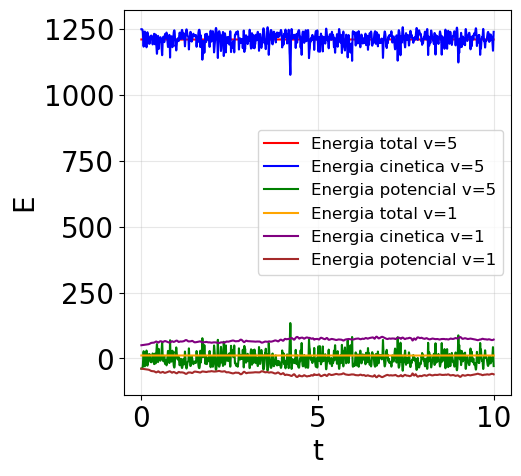

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Represento la energia total del sistema en funcion del tiempo
datos_energia = np.loadtxt("Energia_cinetica_potencial_total_v_5.txt")
datos_energia_1=np.loadtxt("Energia_cinetica_potencial_total.txt")

#solo quiero extraer hasta 10 segundos
E_t=datos_energia_1[:5000, 2]
T_t=datos_energia_1[:5000, 0]
V_t=datos_energia_1[:5000, 1]
E_total_t = datos_energia[:5000, 2]
T_total_t = datos_energia[:5000, 0]
V_total_t = datos_energia[:5000, 1]

t = np.arange(len(E_total_t)) * 0.002

fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(t, E_total_t, label="Energia total v=5", color="red")
ax.plot(t, T_total_t, label="Energia cinetica v=5", color="blue")
ax.plot(t, V_total_t, label="Energia potencial v=5", color="green")
ax.plot(t, E_t, label="Energia total v=1", color="orange")
ax.plot(t, T_t, label="Energia cinetica v=1", color="purple")
ax.plot(t, V_t, label="Energia potencial v=1", color="brown")
ax.tick_params(axis="both", labelsize=20)
ax.set_xlabel("t", fontsize=20)
ax.set_ylabel("E", fontsize=20)

ax.legend(loc="center right", fontsize=12)
ax.grid(alpha=0.3)



fig.savefig("Energia_gas_v_5.png", dpi=300, bbox_inches="tight")
plt.show()

Histogramas

Temperatura media del sistema en situación de equilibrio:
1.213711e+01
Velocidad media en el eje x:
-1.881904e-01


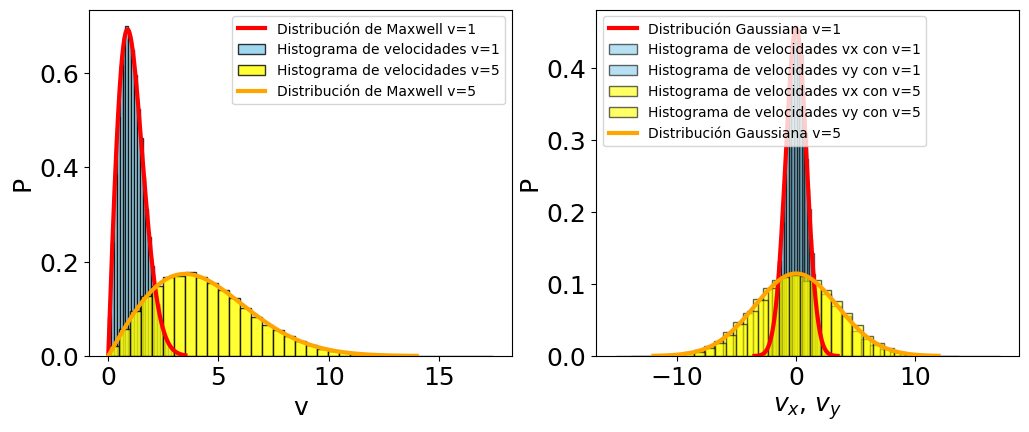

In [2]:
import numpy as np
import matplotlib.pyplot as plt


#*************************************Calculo la temperatura media del sistema cuando se encuentra en equilibrio ***************************************

# Extraigo los datos de las velocidades 
Velocidades = np.loadtxt("Velocidades_atomos_v_5.txt")
velocidades_1=np.loadtxt("Velocidades_atomos_v_1.txt")

#Solo quiero promediar las velocidades de los átomos entre t=100 y t=250 segundos
#es decir, entre los indices 50000 y 125000 
v_x = Velocidades[50000:, 0::2]
v_y = Velocidades[50000:, 1::2]
v_x_1=velocidades_1[50000:, 0::2]
v_y_1=velocidades_1[50000:, 1::2]

# 1) primero, promedio sobre los átomos para obtener la temperatura en cada instante de tiempo

T = 0.5 * np.mean(v_x**2 + v_y**2, axis = 1) # axis =1 indica que haga la media sobre las columnas
vx_m=np.mean(v_x, axis = 1)

# 2) Pormedio sobre las temperaturas que hay en cada instante de tiempo entre los 100 y 250 segundos

T_medio = np.mean(T)
T_medio_1=np.mean(0.5 * np.mean(v_x_1**2 + v_y_1**2, axis = 1))
vx_medio=np.mean(vx_m)

print(f"Temperatura media del sistema en situación de equilibrio:\n{T_medio:e}")
print(f"Velocidad media en el eje x:\n{vx_medio:e}")

#************************************************Hago las distribuciones**********************************************


#Módulo de la velocidad de cada átomo entre t = 100 y t=250 segundos
v = np.sqrt(v_x**2 + v_y**2)
v_1=np.sqrt(v_x_1**2 + v_y_1**2)

# Transformo la matriz v en un vector. La dimension de v transformada en un vector es 75000*100 = 7500000 columnas
v = v.ravel()
v_x = v_x.ravel()
v_y = v_y.ravel()

v_1 = v_1.ravel()
v_x_1 = v_x_1.ravel()
v_y_1 = v_y_1.ravel()


# Función para calcular la distribución de Maxwell con la temperatura media del sistema obtenida antes
def distribucion_Maxwell(v, T):
    P = (1.0 / T) * v * np.exp(-v**2 / (2.0 * T))
    return P

v_teorica = np.linspace(0, 14.0, 150)
dist_Maxwell = distribucion_Maxwell(v_teorica, T_medio)
v_teorica_1 = np.linspace(0, 3.5, 150)
dist_Maxwell_1 = distribucion_Maxwell(v_teorica_1, T_medio_1)

#Funcion para calcular la distribución Gaussiana con la temperatura media del sistema obtenida antes
def distribucion_Gaussiana(v, T):
    P_g = np.sqrt(1.0 / (2.0 * np.pi * T)) * np.exp(-v**2 / (2.0 * T))
    return P_g

v_x_y_teorica = np.linspace(-12, 12, 150)
dist_Gaussiana = distribucion_Gaussiana(v_x_y_teorica, T_medio)
v_x_y_teorica_1 = np.linspace(-3.5, 3.5, 150)
dist_Gaussiana_1 = distribucion_Gaussiana(v_x_y_teorica_1, T_medio_1)

#**************Representación***************************************************

fig, ax = plt.subplots(1,2, figsize=(12, 4.5))

ax[0].plot(v_teorica_1, dist_Maxwell_1, label = "Distribución de Maxwell v=1", color = "red", linewidth = 3)
ax[0].set_xlabel("v", fontsize=18)
ax[0].set_ylabel("P", fontsize=18)
ax[0].hist(v_1, bins = 35, density = True, alpha = 0.8, edgecolor="black", label = "Histograma de velocidades v=1", color = "skyblue")
ax[0].hist(v, bins = 35, density = True, alpha = 0.8, edgecolor="black", label = "Histograma de velocidades v=5", color = "yellow")
ax[0].plot(v_teorica, dist_Maxwell, label = "Distribución de Maxwell v=5", color = "orange", linewidth = 3)
ax[0].tick_params(axis="both", labelsize=18)
ax[0].legend()

ax[1].plot(v_x_y_teorica_1, dist_Gaussiana_1, label = "Distribución Gaussiana v=1", color = "red", linewidth = 3)
ax[1].hist(v_x_1, bins = 35, density = True, alpha = 0.6, edgecolor="black", label = "Histograma de velocidades vx con v=1", color = "skyblue")
ax[1].hist(v_y_1, bins = 35, density = True, alpha = 0.6, edgecolor="black", color = "skyblue", label = "Histograma de velocidades vy con v=1")
ax[1].hist(v_x, bins = 35, density = True, alpha = 0.6, edgecolor="black", label = "Histograma de velocidades vx con v=5", color = "yellow")
ax[1].hist(v_y, bins = 35, density = True, alpha = 0.6, edgecolor="black", color = "yellow", label = "Histograma de velocidades vy con v=5")
ax[1].plot(v_x_y_teorica, dist_Gaussiana, label = "Distribución Gaussiana v=5", color = "orange", linewidth = 3)
ax[1].set_xlabel(r"$v_x$, $v_y$", fontsize=18)
ax[1].set_ylabel("P", fontsize=18)
ax[1].tick_params(axis="both", labelsize=18)
ax[1].legend(loc = "upper left")

fig.savefig("Histograma_velocidades_Lennard_Jones_v_5.png", dpi=300, bbox_inches="tight")